In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pricing = pd.read_csv("../data/processed/pricing_cleaned.csv")

Analyzing the price gap

In [3]:
pricing["Price Gap"] = (
    pricing["Competitor Prices"]
    - pricing["Price"]
)

pricing["Price Gap"].describe()

count    10000.000000
mean        -0.527448
std         39.094067
min        -93.210000
25%        -29.342500
50%         -0.630000
75%         27.472500
max         92.950000
Name: Price Gap, dtype: float64

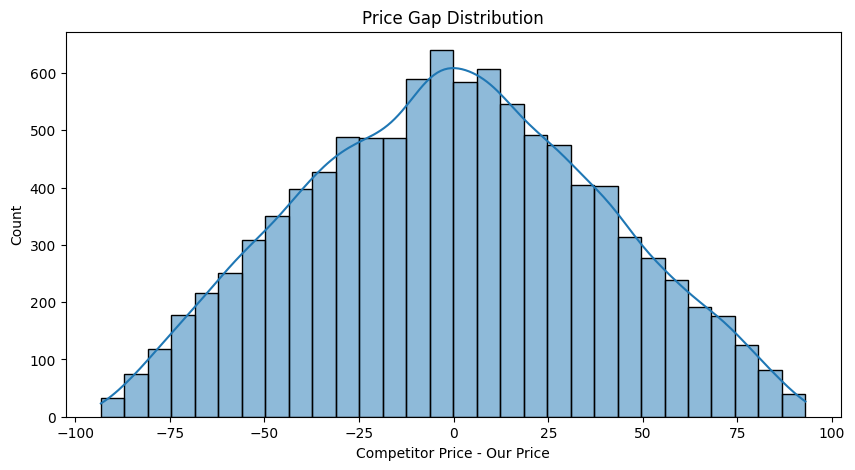

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    pricing["Price Gap"],
    bins=30,
    kde=True
)

plt.title("Price Gap Distribution")
plt.xlabel("Competitor Price - Our Price")

plt.savefig(
    "../reports/figures/pricing/price_gap_distribution.png",
    bbox_inches="tight"
)

plt.show()

Analyze elasticity

In [5]:
pricing["Elasticity Index"].describe()

count    10000.000000
mean         1.502381
std          0.576619
min          0.500000
25%          1.010000
50%          1.500000
75%          2.000000
max          2.500000
Name: Elasticity Index, dtype: float64

In [6]:
pricing["Elasticity Index"].value_counts().head()

Elasticity Index
1.56    67
1.91    66
1.19    65
2.28    64
1.80    64
Name: count, dtype: int64

In [7]:
corr = pricing.corr(numeric_only=True)

corr["Sales Volume"].sort_values(ascending=False)

Sales Volume         1.000000
Discounts            0.016013
Storage Cost         0.011883
Product ID           0.011703
Elasticity Index     0.011058
Price Gap            0.008760
Competitor Prices    0.006822
Store ID             0.006197
Return Rate (%)      0.001547
Customer Reviews    -0.004850
Price               -0.005647
Name: Sales Volume, dtype: float64

In [8]:
pricing["Pricing Recommendation"] = pricing.apply(
    lambda row:
        "Increase Price"
        if row["Elasticity Index"] < 1
        else "Reduce Price",
    axis=1
)

In [9]:
pricing.to_csv(
    "../data/processed/pricing_recommendations.csv",
    index=False
)